In [3]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [8]:
words = open(file='./data/names.txt', mode = 'r').read().splitlines()
# print(words

In [21]:
chars = sorted(set(''.join(words)))
stoi = {k :v+1 for v, k in enumerate(chars)}
stoi['.'] = 0
itos = {k: v for v, k in stoi.items()}
itos

{1: 'a',
 2: 'b',
 3: 'c',
 4: 'd',
 5: 'e',
 6: 'f',
 7: 'g',
 8: 'h',
 9: 'i',
 10: 'j',
 11: 'k',
 12: 'l',
 13: 'm',
 14: 'n',
 15: 'o',
 16: 'p',
 17: 'q',
 18: 'r',
 19: 's',
 20: 't',
 21: 'u',
 22: 'v',
 23: 'w',
 24: 'x',
 25: 'y',
 26: 'z',
 0: '.'}

In [41]:
build_size = 3
X, Y = [], []
for w in words:
    context = [0] * build_size
    # print(w)
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        # print(''.join(itos[i] for i in context),'----->', itos[ix])
        context = context[1:] + [ix]
X = torch.tensor(X).float()
Y = torch.tensor(Y).long()
print(X.shape, Y.shape)

torch.Size([228146, 3]) torch.Size([228146])


In [151]:
### We can adjust the window 
build_size = 3
X, Y = [], []
for w in words:
    chs = w + '.'
    context = [0] * build_size
    for i in chs:
        ix = stoi[i]
        X.append(context)
        Y.append(ix)
        # print(''.join([itos[ix] for ix in context]),'----->',i)
        context = context[1:] + [ix]
X = torch.tensor(X).long()
Y = torch.tensor(Y).long()

In [152]:
### lookup table
C = torch.randn(size=[27,2])

In [153]:
F.one_hot(torch.tensor(5), num_classes= 27).float() @ C

tensor([-1.5408, -0.6291])

In [154]:
C[5,:] ## 索引
C[1:5,:] ## 切片
C[[1,2],:]

tensor([[-0.5890, -0.3415],
        [-1.4220,  0.2251]])

In [155]:
X

tensor([[ 0,  0,  0],
        [ 0,  0,  5],
        [ 0,  5, 13],
        ...,
        [26, 26, 25],
        [26, 25, 26],
        [25, 26, 24]])

In [156]:
X

tensor([[ 0,  0,  0],
        [ 0,  0,  5],
        [ 0,  5, 13],
        ...,
        [26, 26, 25],
        [26, 25, 26],
        [25, 26, 24]])

In [159]:
emb = C[X]
W1 = torch.randn(size=[6,100])
b2 = torch.randn(100)

In [160]:
C[X][:,0,:] ### 二维 索引

tensor([[ 1.2573,  0.7387],
        [ 1.2573,  0.7387],
        [ 1.2573,  0.7387],
        ...,
        [-1.7688,  2.0316],
        [-1.7688,  2.0316],
        [-0.7097,  0.3300]])

In [161]:
torch.cat((C[X][:,0,:], C[X][:,1,:], C[X][:,2,:]), dim= 1)

tensor([[ 1.2573,  0.7387,  1.2573,  0.7387,  1.2573,  0.7387],
        [ 1.2573,  0.7387,  1.2573,  0.7387, -1.5408, -0.6291],
        [ 1.2573,  0.7387, -1.5408, -0.6291,  0.7077, -1.1490],
        ...,
        [-1.7688,  2.0316, -1.7688,  2.0316, -0.7097,  0.3300],
        [-1.7688,  2.0316, -0.7097,  0.3300, -1.7688,  2.0316],
        [-0.7097,  0.3300, -1.7688,  2.0316,  1.8558, -1.2552]])

In [164]:
emb.flatten(1)

tensor([[ 1.2573,  0.7387,  1.2573,  0.7387,  1.2573,  0.7387],
        [ 1.2573,  0.7387,  1.2573,  0.7387, -1.5408, -0.6291],
        [ 1.2573,  0.7387, -1.5408, -0.6291,  0.7077, -1.1490],
        ...,
        [-1.7688,  2.0316, -1.7688,  2.0316, -0.7097,  0.3300],
        [-1.7688,  2.0316, -0.7097,  0.3300, -1.7688,  2.0316],
        [-0.7097,  0.3300, -1.7688,  2.0316,  1.8558, -1.2552]])

In [165]:
import torch.nn as nn
nn.Flatten()(emb)

tensor([[ 1.2573,  0.7387,  1.2573,  0.7387,  1.2573,  0.7387],
        [ 1.2573,  0.7387,  1.2573,  0.7387, -1.5408, -0.6291],
        [ 1.2573,  0.7387, -1.5408, -0.6291,  0.7077, -1.1490],
        ...,
        [-1.7688,  2.0316, -1.7688,  2.0316, -0.7097,  0.3300],
        [-1.7688,  2.0316, -0.7097,  0.3300, -1.7688,  2.0316],
        [-0.7097,  0.3300, -1.7688,  2.0316,  1.8558, -1.2552]])

In [166]:
torch.cat(torch.unbind(emb, dim=1),dim = 1)

tensor([[ 1.2573,  0.7387,  1.2573,  0.7387,  1.2573,  0.7387],
        [ 1.2573,  0.7387,  1.2573,  0.7387, -1.5408, -0.6291],
        [ 1.2573,  0.7387, -1.5408, -0.6291,  0.7077, -1.1490],
        ...,
        [-1.7688,  2.0316, -1.7688,  2.0316, -0.7097,  0.3300],
        [-1.7688,  2.0316, -0.7097,  0.3300, -1.7688,  2.0316],
        [-0.7097,  0.3300, -1.7688,  2.0316,  1.8558, -1.2552]])

In [167]:
### hidden state 
h = torch.tanh(emb.view(emb.size(0), -1) @ W1 + b2)
h.shape

torch.Size([228146, 100])

In [168]:
W2 = torch.randn(size=(100,27))
b2 = torch.randn(27)

logits = h @ W2 + b2

In [169]:
counts = logits.exp()
probs = counts / counts.sum(dim= 1, keepdim= True)
probs[0]

tensor([6.4883e-05, 1.8045e-13, 4.4683e-07, 5.6593e-02, 4.3905e-01, 4.2232e-05,
        4.8685e-01, 2.2218e-05, 1.1801e-09, 2.2413e-14, 1.6381e-02, 6.7824e-07,
        3.5645e-06, 9.3102e-05, 8.2729e-05, 1.6874e-10, 6.6833e-07, 2.2910e-10,
        5.9841e-09, 3.7659e-06, 5.7740e-04, 1.0650e-09, 2.7185e-12, 2.7843e-11,
        4.9679e-08, 9.4821e-08, 2.3921e-04])

In [172]:
loss = -probs[torch.arange(emb.size(0)), Y].log().mean()
loss

tensor(15.9867)

In [173]:
# ---------------- make it respectabele :)---------
X.shape, Y.shape

(torch.Size([228146, 3]), torch.Size([228146]))

In [195]:
g = torch.Generator().manual_seed(217483647)
C = torch.randn(size=(27,2), generator= g)
W1 = torch.randn(size=[6,100], generator= g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn(size=(100,27), generator= g)
b2 = torch.randn(27, generator= g)
params = [C, W1, b1, W2, b2]
sum([p.nelement() for p in params])

3481

In [ ]:
emb = C[X]
h = torch.tanh(emb.view(emb.size(0), -1) @ W1 + b1)
loss = F.cross_entropy(logits, Y)

In [178]:
### 
for p in params:
    p.requires_grad = True
for epoch in range(100):
    for p in params:
        p.grad = None
    emb = C[X]
    h = torch.tanh(emb.view(emb.size(0), -1) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y)
    print(loss.item())
    loss.backward()
    for p in params:
        p.data -= 1 *p.grad



3.800306797027588
3.593935251235962
3.4265735149383545
3.3693490028381348
5.694194316864014
10.420676231384277
9.534966468811035
8.703096389770508
7.267757892608643
8.99328327178955
9.533687591552734
8.359155654907227
7.084299564361572
5.757859230041504
6.510125637054443
5.542685508728027
5.715656280517578
5.72128963470459
5.445694923400879
6.375855445861816
4.329113960266113
3.9573211669921875
4.272889614105225
4.12318229675293
4.051097869873047
3.75759220123291
4.23974084854126
3.4810433387756348
4.024330139160156
4.214895248413086
4.642439842224121
3.8786847591400146
3.9865005016326904
4.595067024230957
4.616857528686523
4.2857184410095215
3.981902599334717
4.748138427734375
4.6639227867126465
4.090915679931641
4.043321132659912
4.321357727050781
3.9086170196533203
4.0657806396484375
3.7911183834075928
3.3964478969573975
3.7258002758026123
4.068298816680908
3.816894769668579
3.8863213062286377
4.003975868225098
3.5445117950439453
4.220177173614502
4.2562150955200195
3.46286320686340

In [183]:
### minibatch
for p in params:
    p.requires_grad = True
for epoch in range(100):
    for p in params:
        p.grad = None
    ix = torch.randint(low=0, high=X.size(0), size=(32,))
    emb = C[X][ix]
    h = torch.tanh(emb.view(emb.size(0), -1) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y[ix])
    print(loss.item())
    loss.backward()
    for p in params:
        p.data -= 1 *p.grad


3.111459732055664
4.464474201202393
10.158777236938477
7.009719371795654
7.248603343963623
6.4232497215271
7.454923152923584
5.110638618469238
8.20649528503418
7.055783271789551
3.9694080352783203
5.183595180511475
9.792377471923828
6.220391750335693
5.453466415405273
5.511577606201172
7.758853435516357
6.207560062408447
6.621753215789795
6.934177398681641
6.7417097091674805
8.182647705078125
7.397797107696533
6.45924186706543
8.543418884277344
8.142680168151855
6.56682825088501
5.234370708465576
7.00994348526001
6.849159240722656
8.142729759216309
7.264723777770996
6.822133541107178
5.83409309387207
7.671737194061279
7.050332069396973
8.772157669067383
7.346891403198242
6.676451206207275
6.544095039367676
9.107020378112793
6.6124348640441895
7.763426303863525
6.2403740882873535
5.433172702789307
8.991043090820312
6.142021179199219
7.5184173583984375
6.924097537994385
6.431179046630859
6.803343772888184
7.242095947265625
7.1419501304626465
5.2762651443481445
4.532423496246338
7.1220297

In [190]:
### dynamic lr
lre = torch.linspace(-3,-1, 1000)
lrs = lre.exp()

In [ ]:
g = torch.Generator().manual_seed(217483647)
C = torch.randn(size=(27,2), generator= g)
W1 = torch.randn(size=[6,100], generator= g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn(size=(100,27), generator= g)
b2 = torch.randn(27, generator= g)
params = [C, W1, b1, W2, b2]
sum([p.nelement() for p in params])

3481

In [200]:
learning_rate = []
losses = []
for p in params:
    p.requires_grad = True
for epoch in range(1000):
    for p in params:
        p.grad = None
    ix = torch.randint(low=0, high=X.size(0), size=(32,))
    emb = C[X][ix]
    h = torch.tanh(emb.view(emb.size(0), -1) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y[ix])
    losses.append(loss.detach().item())
    print(loss.item())
    loss.backward()
    lr = lrs[epoch]
    learning_rate.append(lr)
    for p in params:
        p.data -= lr *p.grad

18.18601417541504
19.011844635009766
18.966936111450195
18.30695915222168
16.268712997436523
20.403444290161133
16.22063636779785
15.995186805725098
15.384111404418945
13.97948169708252
12.983382225036621
13.02670955657959
14.208555221557617
12.560394287109375
12.133793830871582
13.84194278717041
13.000349998474121
9.396951675415039
10.13623046875
12.93947982788086
11.19150161743164
10.680379867553711
12.17292308807373
10.388497352600098
10.844571113586426
10.421598434448242
10.086708068847656
12.234760284423828
10.389802932739258
11.250701904296875
9.79596996307373
10.924118995666504
8.602177619934082
8.511284828186035
8.854990005493164
7.873225688934326
8.817540168762207
8.669501304626465
9.707484245300293
9.459842681884766
7.600255489349365
9.658024787902832
9.094854354858398
9.161419868469238
8.79145622253418
10.283318519592285
7.6344709396362305
8.62126636505127
8.362682342529297
7.762289047241211
6.961397647857666
7.559603214263916
7.2669501304626465
7.356494903564453
7.850210666

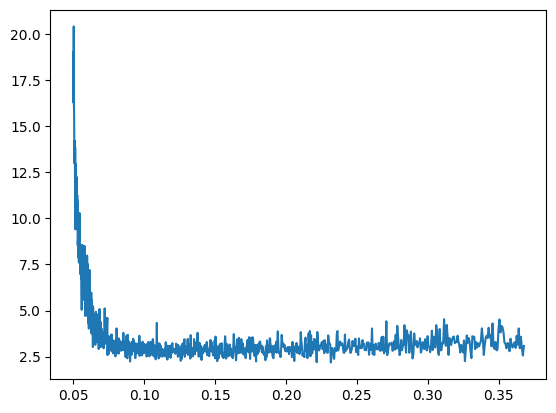

In [201]:
import matplotlib.pyplot as plt
plt.plot(learning_rate, losses)

In [252]:
# while this method has a very high probability to overfit so we need to split all the data into three parts
import numpy as np
words_permutation = np.random.permutation(words)
# print(words[:10])
# print(words_permutation[:10])
def build_datasets(data):
    build_size = 3
    X, Y = [], []
    for w in data:
        chs = w + '.'
        context = [0] * build_size
        for i in chs:
            ix = stoi[i]
            X.append(context)
            Y.append(ix)
            # print(''.join([itos[ix] for ix in context]),'----->',i)
            context = context[1:] + [ix]
    return torch.tensor(X).long(),torch.tensor(Y).long()
    
n1 = int(0.8 * len(words_permutation))
n2 = int(0.9 * len(words_permutation))
Xtr, Ytr = build_datasets(words_permutation[:n1])
Xdev, Ydev = build_datasets(words_permutation[n1:n2])
Xte, Yte = build_datasets(words_permutation[n2:])


In [255]:
g = torch.Generator().manual_seed(217483647)
C = torch.randn(size=(27,10), generator= g)
W1 = torch.randn(size=[30,200], generator= g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn(size=(200,27), generator= g)
b2 = torch.randn(27, generator= g)
params = [C, W1, b1, W2, b2] #### 注意 C也被更新了
sum([p.nelement() for p in params])

11897

In [257]:
# learning_rate = []
# losses = []
for p in params:
    p.requires_grad = True
for epoch in range(1000):
    for p in params:
        p.grad = None
    ix = torch.randint(low=0, high=Xtr.size(0), size=(32,))
    emb = C[X][ix]
    h = torch.tanh(emb.view(emb.size(0), -1) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Ytr[ix])
    losses.append(loss.detach().item())
    print(loss.item())
    loss.backward()
    # lr = lrs[epoch]
    # learning_rate.append(lr)
    for p in params:
        p.data -= 0.01 *p.grad
print(loss.item())

3.314685344696045
3.7663941383361816
3.858853578567505
2.9051589965820312
5.199591159820557
3.3010072708129883
3.758355140686035
2.952521800994873
3.1403346061706543
3.5264134407043457
4.498703956604004
3.4575703144073486
3.5639100074768066
3.136779546737671
4.924795150756836
3.6421706676483154
3.7238800525665283
4.2649335861206055
4.064273357391357
3.1052794456481934
4.1309332847595215
2.606173276901245
4.646221160888672
3.526200771331787
3.968801259994507
3.3574106693267822
3.502647876739502
3.1674327850341797
3.0920355319976807
3.863893508911133
3.522057294845581
3.497929334640503
3.567730665206909
3.818816661834717
3.3463401794433594
4.485827445983887
4.0543317794799805
3.6238927841186523
4.297767639160156
3.303617000579834
2.8073346614837646
4.485424041748047
4.549983501434326
3.994962453842163
3.8360297679901123
3.815725564956665
3.3121395111083984
4.005970478057861
3.822299003601074
3.2125141620635986
3.153841972351074
3.8355746269226074
3.8037259578704834
2.913543939590454
4.29

In [249]:
emb = C[Xdev]
h = torch.tanh(emb.view(emb.size(0), -1) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ydev)
loss.item()

2.8812172412872314

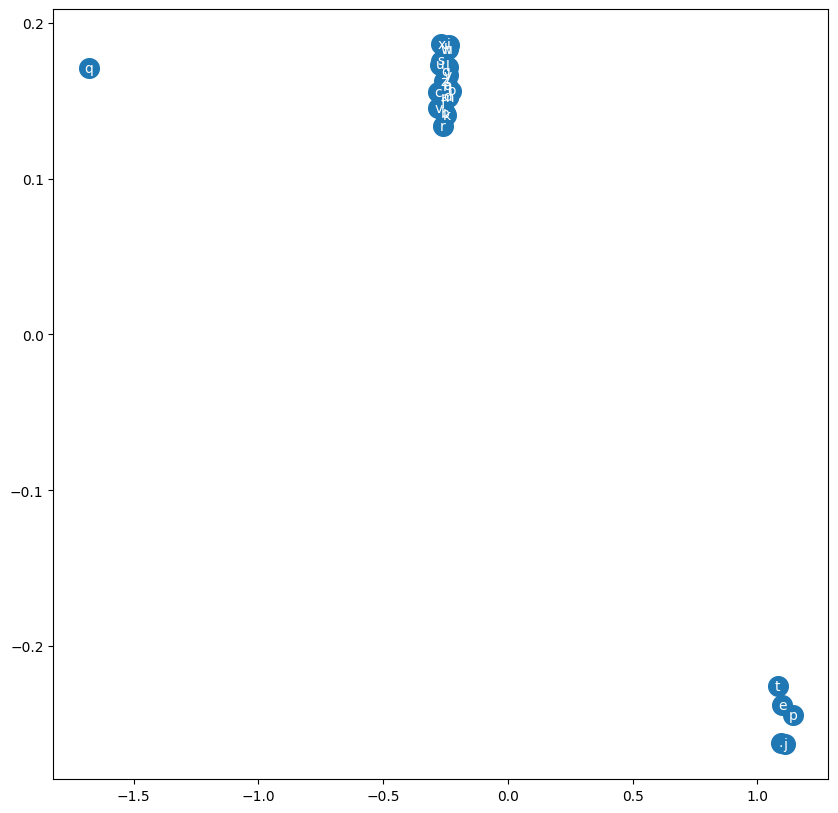

In [251]:
plt.figure(figsize=(10,10))
plt.scatter(C[:,0].detach().numpy(),C[:,1].detach().numpy(), s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha='center', va='center', color='white')